In [6]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

np.set_printoptions(precision=4, suppress=True)

In [3]:
# Loading dataset
df = pd.read_csv('/content/usina_with_outliers.csv')
print("\nColumns:")
print(df.columns.tolist())

display(df.head())
print(len(df))


Columns:
['AT', 'V', 'AP', 'RH', 'PE']


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


9568


# **Part 1: Outlier Detection and Removal Using Cook's Distance**

1. Cook's Distance is specifically defined for OLS regression; for this reason, I chose Linear Regression to implement Cook's Distance. With Ridge and Lasso regression, which shrinks coefficients and changes how influence is distributed across points, Cook's Distance becomes less "standard" and harder to interpret. Since our goal is to identify influential outliers (and not necessarily improve generalization), Linear Regression is a better fit.

2. I used Statsmodel OLS compared to scikit-learn because it was designed for statistical analysis and has built-in tools for influence diagnostics such as Cook's Distance. On the other hand, scikit-learn is primarily designed for prediction rather than statistical analysis.

In [4]:
X = df[["AT", "V", "AP", "RH"]]
Y = df["PE"]
X_sm = sm.add_constant(X)

model = sm.OLS(Y, X_sm).fit()
influence = OLSInfluence(model)
cooks_distance = influence.cooks_distance[0]

# Using the standard threshold rule of 4/n
n = len(df)
threshold = 4/n
outlier_mask = cooks_distance > threshold

df_clean = df.loc[~outlier_mask].copy()
df_clean.to_csv("usina.csv", index=False)
df_clean.head()
print(len(df_clean))

9448


# **Part 2: Train/Test Evaluation Before vs After Outlier Removal**

In [8]:
# Helper function for all models
def evaluate_model(model, X_train, y_train, X_test, y_test):
  model.fit(X_train, y_train)

  yhat_train = model.predict(X_train)
  yhat_test = model.predict(X_test)

  return {
      "Train MSE": mean_squared_error(y_train, yhat_train),
      "Train MAE": mean_absolute_error(y_train, yhat_train),
      "Train R2": r2_score(y_train, yhat_train),
      "Test MSE": mean_squared_error(y_test, yhat_test),
      "Test MAE": mean_absolute_error(y_test, yhat_test),
      "Test R2": r2_score(y_test, yhat_test)
  }

# Helper function for results with vs. without outliers
def with_vs_without(csv_path, random_state=42):
  df = pd.read_csv(csv_path)
  X = df[["AT", "V", "AP", "RH"]]
  y = df["PE"]

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.3, random_state=random_state
  )

  lambda_values = [0.01, 0.1, 1, 10, 100]
  rows = []

  # Linear Regression
  res = evaluate_model(LinearRegression(), X_train, y_train, X_test, y_test)
  rows.append({"Model": "Linear Regression", **res})

  # Ridge Regression
  for l in lambda_values:
    ridge = Ridge(alpha=l, random_state=random_state)
    res = evaluate_model(ridge, X_train, y_train, X_test, y_test)
    rows.append({"Model": f"Ridge (λ={l})", **res})

  # Lasso Regression
  for l in lambda_values:
    lasso = Lasso(alpha=l, random_state=random_state)
    res = evaluate_model(lasso, X_train, y_train, X_test, y_test)
    rows.append({"Model": f"Lasso (λ={l})", **res})

  return pd.DataFrame(rows)

In [9]:
results_with_outliers = with_vs_without("/content/usina_with_outliers.csv")
results_with_outliers

,Model,Train MSE,Train MAE,Train R2,Test MSE,Test MAE,Test R2
0,Linear Regression,123.384207,5.198679,0.650171,125.113389,5.052458,0.642574
1,Ridge (λ=0.01),123.384207,5.198679,0.650171,125.113389,5.052458,0.642574
2,Ridge (λ=0.1),123.384207,5.198680,0.650171,125.113392,5.052459,0.642574
3,Ridge (λ=1),123.384207,5.198685,0.650171,125.113421,5.052463,0.642574
4,Ridge (λ=10),123.384207,5.198737,0.650171,125.113705,5.052513,0.642573
5,Ridge (λ=100),123.384213,5.199261,0.650171,125.116548,5.053003,0.642565
6,Lasso (λ=0.01),123.384210,5.198858,0.650171,125.115332,5.052626,0.642568
7,Lasso (λ=0.1),123.384607,5.201739,0.650169,125.134495,5.055348,0.642514
8,Lasso (λ=1),123.421151,5.229507,0.650066,125.338356,5.083092,0.641931
9,Lasso (λ=10),126.141514,5.540418,0.642353,128.902136,5.408803,0.631750


In [10]:
results_clean = with_vs_without("/content/usina.csv")
results_clean

,Model,Train MSE,Train MAE,Train R2,Test MSE,Test MAE,Test R2
0,Linear Regression,19.864671,3.596396,0.931369,20.396772,3.624773,0.930302
1,Ridge (λ=0.01),19.864671,3.596396,0.931369,20.396772,3.624773,0.930302
2,Ridge (λ=0.1),19.864671,3.596397,0.931369,20.396770,3.624773,0.930302
3,Ridge (λ=1),19.864671,3.596400,0.931369,20.396750,3.624774,0.930302
4,Ridge (λ=10),19.864672,3.596430,0.931369,20.396549,3.624783,0.930303
5,Ridge (λ=100),19.864758,3.596742,0.931369,20.394626,3.624880,0.930310
6,Lasso (λ=0.01),19.864675,3.596368,0.931369,20.396738,3.624754,0.930302
7,Lasso (λ=0.1),19.865263,3.596855,0.931367,20.392600,3.624890,0.930316
8,Lasso (λ=1),19.929852,3.605523,0.931144,20.414755,3.631153,0.930241
9,Lasso (λ=10),25.685683,4.086632,0.911258,26.157253,4.120464,0.910618


## **Analysis**
1. When trained on the dataset with outliers, all models had much higher train and test errors, along with significantly lower test R^2 (~0.64 for most models). On the other hand, the dataset without outliers showed significant improvement in train and test errors, indicating better generalization (test R^2 values were closer to 1 at ~0.93 for most models).

2. The train and test metrics were similar in both datasets. This suggests that overfitting is not a major issue, but rather the presence of influential outliers distorting the regression fit.

3. Ridge regression performs similarly to linear regression across all lambda values, indicating that regularization doesn't significantly affect this dataset (in a positive way). Lasso regression also performs similarly for smaller lambda values, but performance noticeably degrades for larger lambda values as important coefficients are overly shrunk or eliminated as a whole.

# **Part 3: Reliability of Coefficients**

1. To determine the reliability of coefficients (not improve prediction performance), I chose to use Linear Regression. It allows us to directly measure uncertainty using standard errors and t-statistics. Ridge and Lasso Regression intentionally shrinks coefficients (regularization), which helps with overfitting but makes the coefficients harder to interpret for reliability analysis since the coefficients are biased.

2. I chose Statsmodels over scikit-learn as it is designed for statistical analysis and inference. It directly provides, standard errors, t-statistics, p-values, and confidence intervals for regression coefficients: all metrics used for assessing the reliability of coefficients. Scikit-learn mainly focuses on prediction accuracy and doesn't provide the built-in tools that Statsmodels does.

3. I wouldn't scale the IVs or the DVs to determine coefficient reliability. Doing so would change the magnitude of both coefficients and their standard errors, making the reliability analysis less meaningful (since it is measured by standard errors and t-statistics, which are based on the original scale of the data). Scaling is more important when comparing feature importance or applying regularization.

In [13]:
df = pd.read_csv("usina.csv")

X = df[["AT", "V", "AP", "RH"]]
y = df["PE"]

X_sm = sm.add_constant(X)

model = sm.OLS(y, X_sm).fit()
# model.summary()

coef_table = pd.DataFrame({
    "Coefficients": model.params,
    "Std. Error": model.bse,
    "t-stat": model.tvalues,
    "p-value": model.pvalues
})

coef_table

,Coefficients,Std. Error,t-stat,p-value
const,440.999323,9.742711,45.264539,0.000000e+00
AT,-1.954640,0.015139,-129.113036,0.000000e+00
V,-0.237885,0.007196,-33.056481,7.527041e-227
AP,0.074638,0.009454,7.894540,3.238569e-15
RH,-0.148856,0.004034,-36.897303,1.578009e-278


In [14]:
most_reliable = coef_table["t-stat"].abs().idxmax()
least_reliable = coef_table["t-stat"].abs().idxmin()

print(f"Most reliable coefficient: {most_reliable}")
print(f"Least reliable coefficient: {least_reliable}")

Most reliable coefficient: AT
Least reliable coefficient: AP


I used the magnitude of the t-statistic to determine the reliablity of the coefficients. A larger t-value would indicate a more reliable estimate. Based on this analysis, **AT** is the most reliable coefficient, while **AP** is the least reliable. This means that AP has a smaller t-statistic and larger relative uncertainty; its estimated effect is more sensitive to variations in data.

# **Part 4: Most vs. Least Important Features**

1. To determine the importance of features, I chose to use Linear Regression. After standardizing the input features, it would allow the coefficient magnitudes to be directly compared to determine which features have the most and least effect on the prediction.

2. I chose scikit-learn over Statsmodel, as it provides convenient tools for feature scaling and model fitting, both of which are essential for determining feature importance.

3. For this task, I scaled the IVs, but not the DVs. Scaling the IVs ensures that all features are on the same scale, making their coefficient magnitudes directly comparable. Without scaling, features measured in different units could appear more or less important due to their scale rather than their actual effect. Scaling the DV is unnecessary, as it doesn't affect the importance of features.

In [8]:
df = pd.read_csv("usina.csv")

X = df[["AT", "V", "AP", "RH"]]
y = df["PE"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_,
    "Abs Coefficient Value": np.abs(model.coef_)
})

coef_df.sort_values("Abs Coefficient Value", ascending=False)

,Feature,Coefficient,Abs Coefficient Value
0,AT,-14.556614,14.556614
1,V,-3.030737,3.030737
3,RH,-2.197120,2.197120
2,AP,0.442513,0.442513


After standardizing the input features to ensure that all features are on the same scale, I compared the absolute values of the regression coefficients. Based on this analysis, **AT** has the largest impact on the result, while **AP** has the smallest impact.

# **Part 5: Regularization Paths**

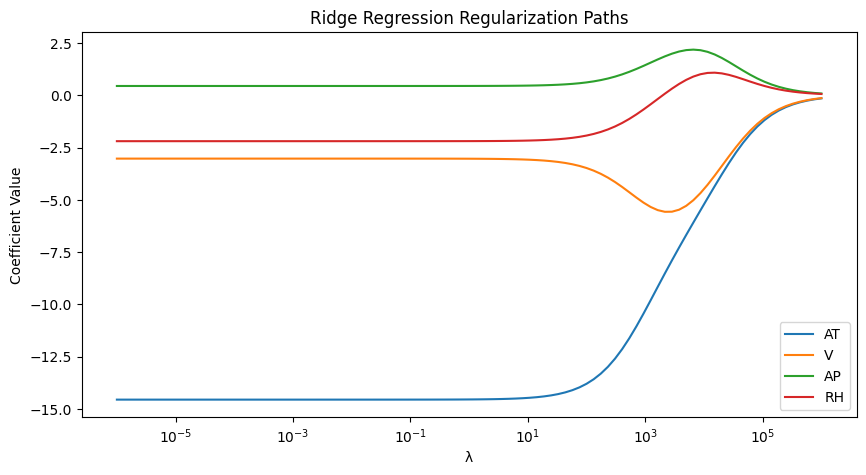

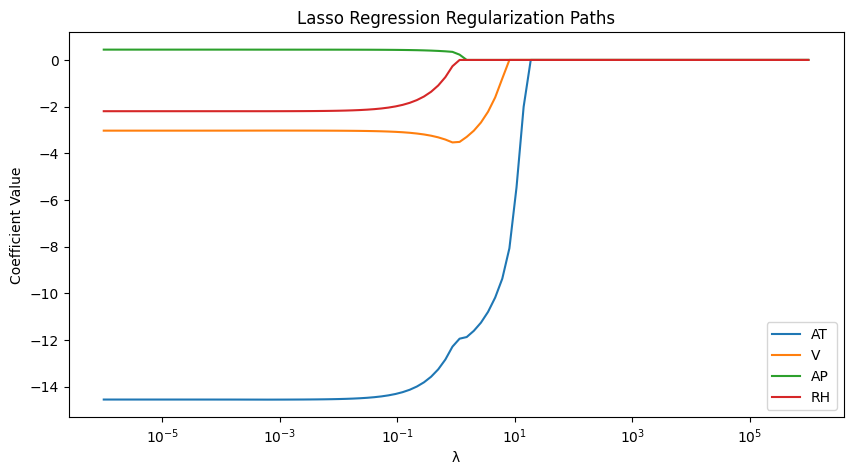

In [12]:
df = pd.read_csv("usina.csv")

X = df[["AT", "V", "AP", "RH"]]
y = df["PE"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lambda_values = np.logspace(-6, 6, 100)

# Ridge Coefficients
ridge_coefs = []
for l in lambda_values:
  ridge = Ridge(alpha=l)
  ridge.fit(X_scaled, y)
  ridge_coefs.append(ridge.coef_)
ridge_coefs = np.array(ridge_coefs)

plt.figure(figsize=(10, 5))
for i, feature in enumerate(X.columns):
  plt.plot(lambda_values, ridge_coefs[:, i], label=feature)

plt.xscale("log")
plt.xlabel("λ")
plt.ylabel("Coefficient Value")
plt.title("Ridge Regression Regularization Paths")
plt.legend()
plt.show()

# Lasso Coefficients
lasso_coefs = []
for l in lambda_values:
  lasso = Lasso(alpha=l)
  lasso.fit(X_scaled, y)
  lasso_coefs.append(lasso.coef_)
lasso_coefs = np.array(lasso_coefs)

plt.figure(figsize=(10, 5))
for i, feature in enumerate(X.columns):
  plt.plot(lambda_values, lasso_coefs[:, i], label=feature)

plt.xscale("log")
plt.xlabel("λ")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regression Regularization Paths")
plt.legend()
plt.show()

## **Analysis**

1. As lambda increases in the Ridge Regression plot, coefficients are shrunk to control model complexity and reduce variance. It strongly reduces error by reducing large coefficients and helps prevent "wild" coefficient values caused by noisy data. In the Lasso Regression plot, increasing lambda causes coefficients to shrink individually, and some coefficients are driven to 0. It improves interpretability by creating fewer nonzero coefficients.

2. Ridge Regression is better under multicollinearity in IVs because it shrinks coefficients smoothly without removing correlated features. This helps stabilize the model when predictors have high correlation and reduces the variance caused by multicollinearity. On the other hand, Lasso Regression may eliminate one correlated feature while keeping another, which can cause issues especially if the features are strongly correlated.

3. Lasso Regression is better for feature selection, as it drives some coefficients to exactly 0 as lambda increases. This helps remove less important features from the model, creating a sparse and more predictable set of predictors. Ridge Regression keeps all coefficients nonzero, making it not suitable for the task.